# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

!pip install causaldata
import causaldata



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for causaldata: filename=causaldata-0.1.5-py3-none-any.whl size=2767646 sha256=0731b46bb3ab15f09e290499d0c8d27e64e2659cf6ba2547ae05d4155a6b3de4
  Stored in directory: /root/.cache/pip/wheels/fd/42/c7/7665a1c716f3a1518c4f42abcd23054a5701aca1d118c348d7
Successfully built causaldata


## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


In [22]:
import pandas as pd

# Load the data
df = causaldata.nsw_mixtape.load_pandas().data

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Data on the National Supported Work Demonstration (NSW) job-training program experiment:")
print(df)




Number of samples: 445
Number of features: 11
Data on the National Supported Work Demonstration (NSW) job-training program experiment:
                  data_id  treat  age  educ  black  hisp  marr  nodegree  \
0    Dehejia-Wahba Sample      1   37    11      1     0     1         1   
1    Dehejia-Wahba Sample      1   22     9      0     1     0         1   
2    Dehejia-Wahba Sample      1   30    12      1     0     0         0   
3    Dehejia-Wahba Sample      1   27    11      1     0     0         1   
4    Dehejia-Wahba Sample      1   33     8      1     0     0         1   
..                    ...    ...  ...   ...    ...   ...   ...       ...   
440  Dehejia-Wahba Sample      0   21     9      1     0     0         1   
441  Dehejia-Wahba Sample      0   28    11      1     0     0         1   
442  Dehejia-Wahba Sample      0   29     9      0     1     0         1   
443  Dehejia-Wahba Sample      0   25     9      1     0     1         1   
444  Dehejia-Wahba Sample    

In [24]:
# Extract sets of variables from the dataset
Y74 = df['re74'] # real income in 1974
Y75 = df['re75']
Y78 = df['re78']

lY74 = np.log(df['re74']) # logged real income in 1974
lY75 = np.log(df['re75'])
lY78 = np.log(df['re78'])
D = df['treat'] # treatment
ID = df['data_id'] # sample ID (only from 1 datasource)
X = df.drop(['re74', 're75', 're78', 'treat', 'data_id' ], axis=1) # create & save matrix for all other (x) variables


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


In [3]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values


,0
data_id,0
treat,0
age,0
educ,0
black,0
hisp,0
marr,0
nodegree,0
re74,0
re75,0


There are no missing values.

## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


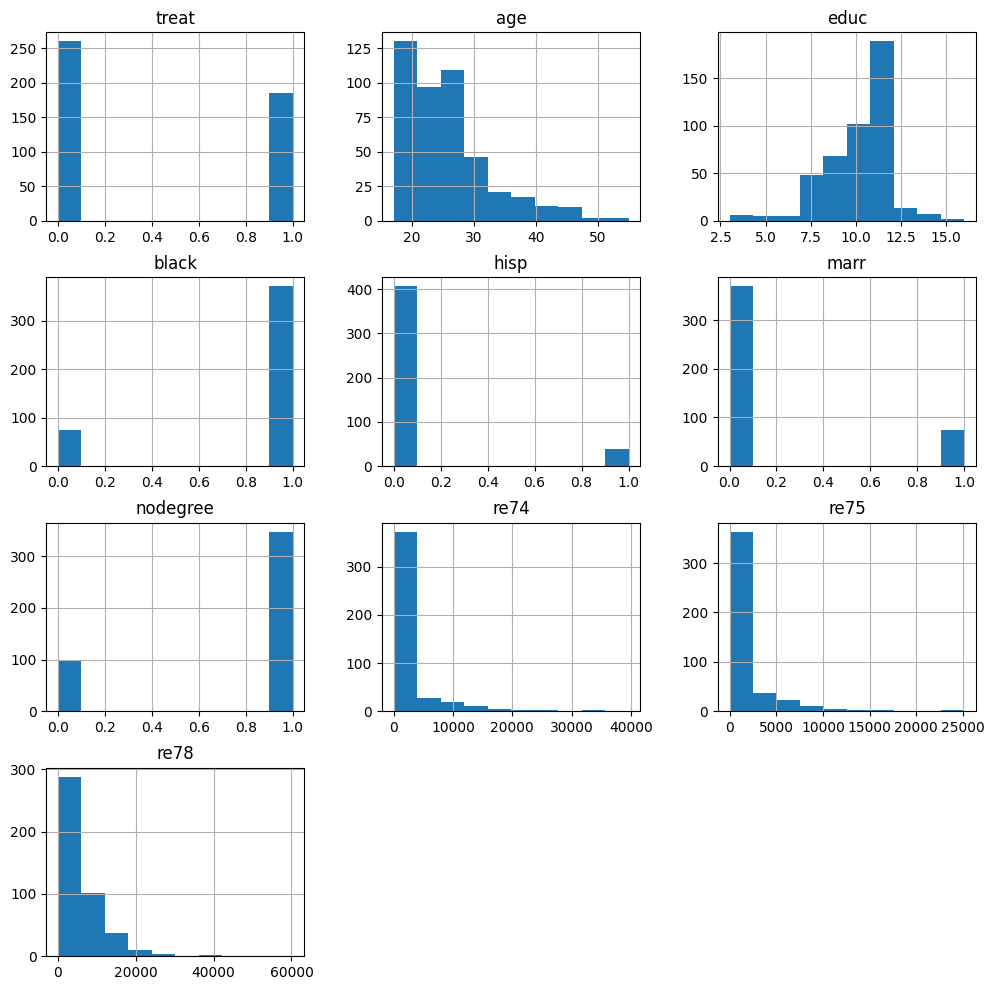

In [26]:
# Example: Plotting histograms of all numerical features
df.hist(figsize=(12, 12))
plt.show()


According to the histograms, treat, black, hisp, mar, nodegree are dummy variables for the treatment, being black, being of hispanic ethnicity, being married and having no degree.

The shares of people not being treated (around 260) and being treated (around 190) in the sample is more or less similar, with the treatment group being slightly larger. Regarding all other dummies, there are way more black people in the sample than white people, more non-hispanic people vs. hispanic people, more non-married people than married people and more people having no degree vs. having a degree.

The distribution of the years of age likely has a mean around 22 years and is a little skewed to the right. The distribution of years of education has its mean around 11 years and is skewed to the left.

Finally, all measures of real earnings (in the years 1974, 1975 and 1978) are extremely skewed to the right due to high outliers in each year. A solution to improve the distribution will be to use the log of real income.

## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


<Axes: xlabel='treat', ylabel='count'>

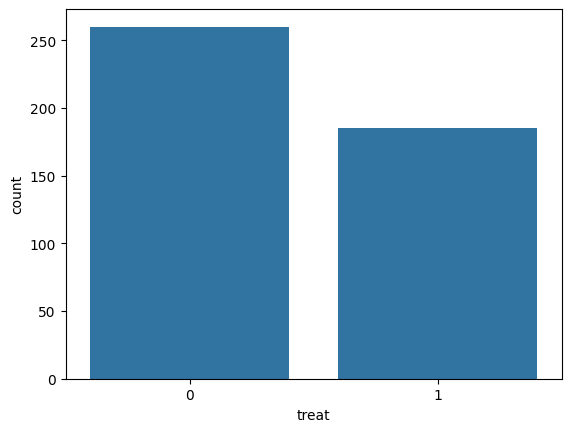

In [37]:
# Checking for class imbalance in a classification problem
sb.countplot(x='treat', data=df)


As the treated group is slightly larger than the non-treated control group, there might be some bias introduced by class imbalance, which we need to take into account in our analysis.

In [ ]:
# Check for selection bias
sb.countplot(x='black', data=df)

As we've seen in the previous section, there are more black people in the sample than non-black people. This might be an indicator that the sample was taken from a neighborhood with a majority of black people and might therefore not be representative for a country's whole population. Therefore, there might be selection bias.

Similar evidence might be seen from the other dummy graphs, as there are more people without a degree, and more non-married people. This futher indicates that the sample might not be representative for the whole population. (the number of non-hispanics might actually be quite representative).

## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


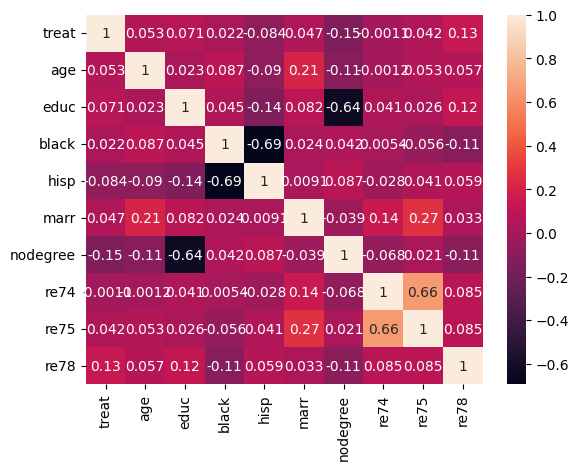

In [35]:
# Plotting a heatmap to show feature correlations
temp = df.drop(['data_id'], axis=1)

correlation_matrix = temp.corr()
sb.heatmap(correlation_matrix, annot=True)
plt.show()


Overall, cofferations look quite good with most of them being very low, and none of the features is highly correlated with the treatment or target variables.
However, the correlation between having no degree and years of education is -0.64 and being hispanic is correlated with being black at -0.69, so one might need to try multiple model specifications excluding one of the features (or use methods such as LASSO regression) to avoid multicollinearity issues.
